## 1. Lectura del dataset  

- Utilizar **Pandas** para cargar el dataset en un `DataFrame`.  
- Explorar la estructura del dataset: número de filas, columnas y tipos de variables.  
- Obtener **estadísticas descriptivas**:  
  - Media  
  - Desviación estándar  
  - Valores mínimos y máximos  


# Importaciones
Importamos las librerías necesarias para realizar cálculos numéricos, manejar el dataset y generar visualizaciones.

In [277]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ds = pd.read_csv("Student_Performance.csv")

print("Dimensiones del dataset:",ds.shape)
print("Filas del dataset:",ds.shape[0])
print("Columnas del dataset:",ds.columns)
print("primeras 5 filas del dataset:\n",ds.head())
print("tipo de dato por cada columna:\n",ds.dtypes)

Dimensiones del dataset: (10000, 6)
Filas del dataset: 10000
Columnas del dataset: Index(['Hours Studied', 'Previous Scores', 'Extracurricular Activities',
       'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index'],
      dtype='object')
primeras 5 filas del dataset:
    Hours Studied  Previous Scores Extracurricular Activities  Sleep Hours  \
0              7               99                        Yes            9   
1              4               82                         No            4   
2              8               51                        Yes            7   
3              5               52                        Yes            5   
4              7               75                         No            8   

   Sample Question Papers Practiced  Performance Index  
0                                 1               91.0  
1                                 2               65.0  
2                                 2               45.0  
3                   

In [278]:


# Ver cuántos valores faltantes hay por columna
print(ds.isnull().sum())

# Ver si existe alguna fila con al menos un valor faltante
print(ds.isnull().any(axis=1).sum(), "filas con valores faltantes")

# Opcional: mostrar esas filas
rows_with_na = ds[ds.isnull().any(axis=1)]
print(rows_with_na)

print(ds["Extracurricular Activities"].unique())

print(ds.describe())


Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64
0 filas con valores faltantes
Empty DataFrame
Columns: [Hours Studied, Previous Scores, Extracurricular Activities, Sleep Hours, Sample Question Papers Practiced, Performance Index]
Index: []
['Yes' 'No']
       Hours Studied  Previous Scores   Sleep Hours  \
count   10000.000000     10000.000000  10000.000000   
mean        4.992900        69.445700      6.530600   
std         2.589309        17.343152      1.695863   
min         1.000000        40.000000      4.000000   
25%         3.000000        54.000000      5.000000   
50%         5.000000        69.000000      7.000000   
75%         7.000000        85.000000      8.000000   
max         9.000000        99.000000      9.000000   

       Sample Question Papers Practiced  Performance Index

Obtencion de estadisticas descriptivas: media, desviación
estándar, valores mı́nimos y máximos.

In [279]:
print("Media de horas de estudio:", ds['Hours Studied'].mean())
print("Desviación estándar de horas de estudio:", ds['Hours Studied'].std())
print("Valor mínimo de horas de estudio:", ds['Hours Studied'].min())
print("Valor máximo de horas de estudio:", ds['Hours Studied'].max())
print("\n")
print("Media de calificaciones:", ds['Previous Scores'].mean())
print("Desviación estándar de calificaciones:", ds['Previous Scores'].std())
print("Valor mínimo de calificaciones:", ds['Previous Scores'].min())   
print("Valor máximo de calificaciones:", ds['Previous Scores'].max())
print("\n")
print("Media de horas de sueno:", ds['Sleep Hours'].mean())
print("Desviación estándar de horas de sueno:", ds['Sleep Hours'].std())
print("Valor mínimo de horas de sueno:", ds['Sleep Hours'].min())
print("Valor máximo de horas de sueno:", ds['Sleep Hours'].max())
print("\n")

# Estadísticas descriptivas para todas las columnas numéricas
print(ds[['Hours Studied', 'Previous Scores', 'Sleep Hours', 'Performance Index']].describe())





Media de horas de estudio: 4.9929
Desviación estándar de horas de estudio: 2.5893087961856156
Valor mínimo de horas de estudio: 1
Valor máximo de horas de estudio: 9


Media de calificaciones: 69.4457
Desviación estándar de calificaciones: 17.34315225104711
Valor mínimo de calificaciones: 40
Valor máximo de calificaciones: 99


Media de horas de sueno: 6.5306
Desviación estándar de horas de sueno: 1.6958629765177118
Valor mínimo de horas de sueno: 4
Valor máximo de horas de sueno: 9


       Hours Studied  Previous Scores   Sleep Hours  Performance Index
count   10000.000000     10000.000000  10000.000000       10000.000000
mean        4.992900        69.445700      6.530600          55.224800
std         2.589309        17.343152      1.695863          19.212558
min         1.000000        40.000000      4.000000          10.000000
25%         3.000000        54.000000      5.000000          40.000000
50%         5.000000        69.000000      7.000000          55.000000
75%         7

In [280]:
duplicates = ds[ds.duplicated()]
print("Filas duplicadas:", len(duplicates))


print(ds.isnull().sum())

ds = ds.drop_duplicates()
print("Nuevo tamaño del dataset:", ds.shape)


Filas duplicadas: 127
Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64
Nuevo tamaño del dataset: (9873, 6)


# 2. Análisis de características  

Realizar un **análisis exploratorio de datos (EDA)** que incluya:  

- Histogramas y boxplots de variables numéricas.  
- Diagramas de dispersión entre características y el *target*.  
- Matriz de correlación (con mapa de calor).  
- Cualquier otra visualización que considere necesaria.  

Además:  

- Identificar y reportar **datos sobresalientes** (outliers), y aplicarles tratamiento en caso de existir.  
- En caso de no existir, justificar la ausencia de datos sobresalientes.  

El análisis debe incluir no solo visualizaciones, sino también **interpretación de los resultados**.


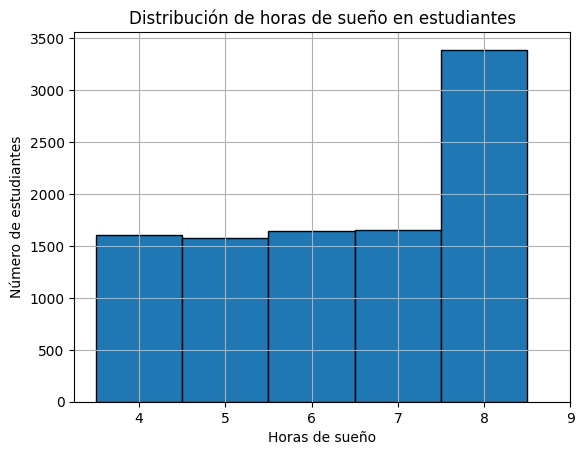

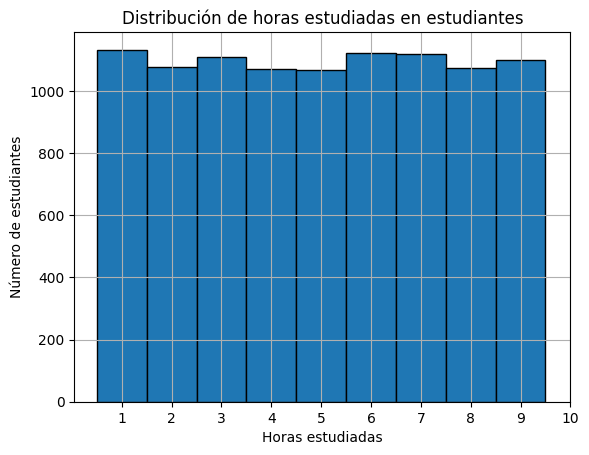

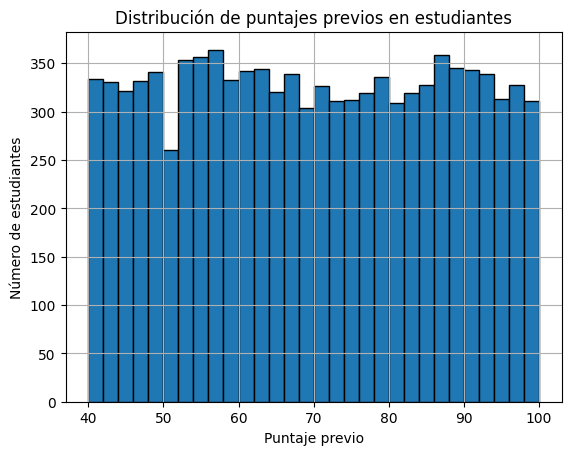

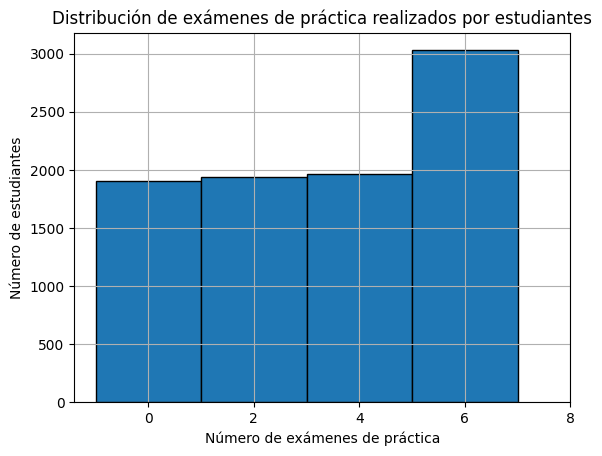

In [281]:

import matplotlib.pyplot as plt

# Histograma de horas de sueño
ds['Sleep Hours'].hist(
    bins=range(4, 10),   # de 4 a 9 inclusive
    edgecolor='black',
    align='left'         # para que cada barra quede alineada al número entero
)

plt.title("Distribución de horas de sueño en estudiantes")
plt.xlabel("Horas de sueño")
plt.ylabel("Número de estudiantes")
plt.xticks(range(4, 10))  # marcas en el eje x de 4 a 9
plt.show()


ds["Hours Studied"].hist(
    bins=range(1, 11),      # de 1 a 10 inclusive
    edgecolor='black',
    align='left'
)
plt.title("Distribución de horas estudiadas en estudiantes")
plt.xlabel("Horas estudiadas")
plt.ylabel("Número de estudiantes")
plt.xticks(range(1, 11))
plt.show()

# Histograma de puntajes previos
ds["Previous Scores"].hist(
    bins=range(40, 101, 2),  # supongamos puntajes de 0 a 100 en intervalos de 10
    edgecolor='black'
)
plt.title("Distribución de puntajes previos en estudiantes")
plt.xlabel("Puntaje previo")
plt.ylabel("Número de estudiantes")
plt.xticks(range(40, 101, 10))
plt.show()

ds["Sample Question Papers Practiced"].hist(
    bins=range(0, 10, 2),  # de 0 a 20 en intervalos de 2
    edgecolor='black',
    align='left'
)
plt.title("Distribución de exámenes de práctica realizados por estudiantes")
plt.xlabel("Número de exámenes de práctica")
plt.ylabel("Número de estudiantes")
plt.xticks(range(0, 10, 2))
plt.show()


Se puede observar que en los histogramas horas de sueno y en el de numero de examenes de practica existe un sesgo debido a la asimetria del histograma podemos ver como ambos tienen un sesgo a la derecha por lo tanto las variables no estan uniformemente distribuidas. Por lo anterior es probable que a la hora de realizar predicciones estos datos agreguen ruido o residuos a las predicciones. 

In [282]:
import numpy as np
num_cols = ['Hours Studied', 'Previous Scores', 'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index']

for col in num_cols:
    Q1 = ds[col].quantile(0.25)
    Q3 = ds[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ds[(ds[col] < Q1 - 1.5*IQR) | (ds[col] > Q3 + 1.5*IQR)]
    print(f"{col}: {len(outliers)} outliers")




Hours Studied: 0 outliers
Previous Scores: 0 outliers
Sleep Hours: 0 outliers
Sample Question Papers Practiced: 0 outliers
Performance Index: 0 outliers


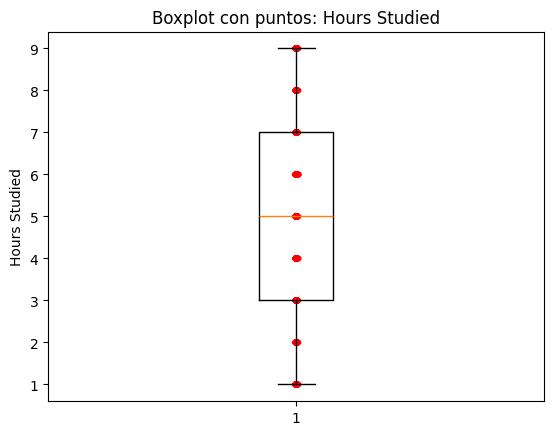

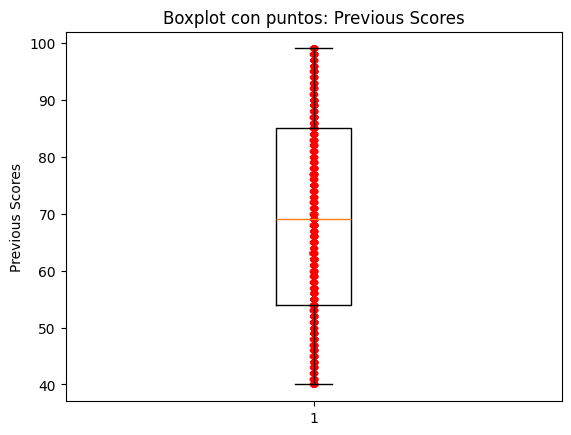

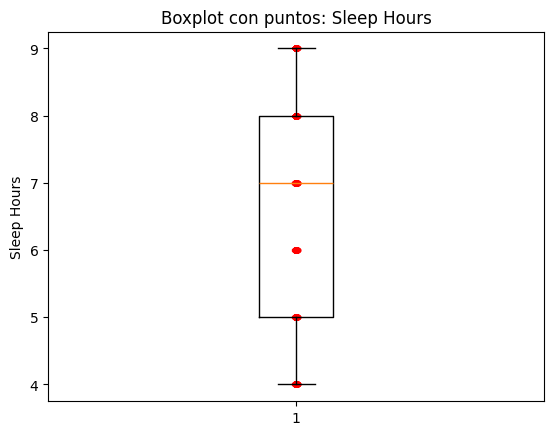

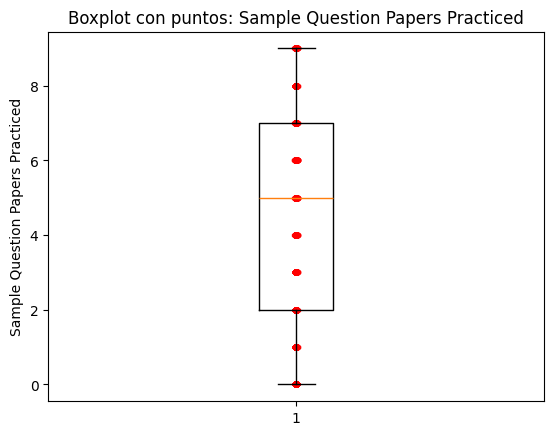

In [283]:
num_cols = ['Hours Studied', 'Previous Scores', 'Sleep Hours', 'Sample Question Papers Practiced']

for col in num_cols:
    plt.figure()
    
    # Boxplot
    plt.boxplot(ds[col])
    
    # Puntos individuales
    y = ds[col].values
    x = np.random.normal(1, 0.001, size=len(y))  # genera un pequeño jitter en x para no superponer todos los puntos
    plt.scatter(x, y, alpha=0.5, color='red', s=10)  # s = tamaño de los puntos
    
    plt.title(f"Boxplot con puntos: {col}")
    plt.ylabel(col)
    plt.show()


**se puede observar que no hay datos sobresalientes de acuerdo a los diagramas de cajas**
No hay existencia de outliers como se puede observear en los diagramas de cajas teniendo el minimo en Q1-1.5*IQR y el maximo en Q3+1.5*IQR 

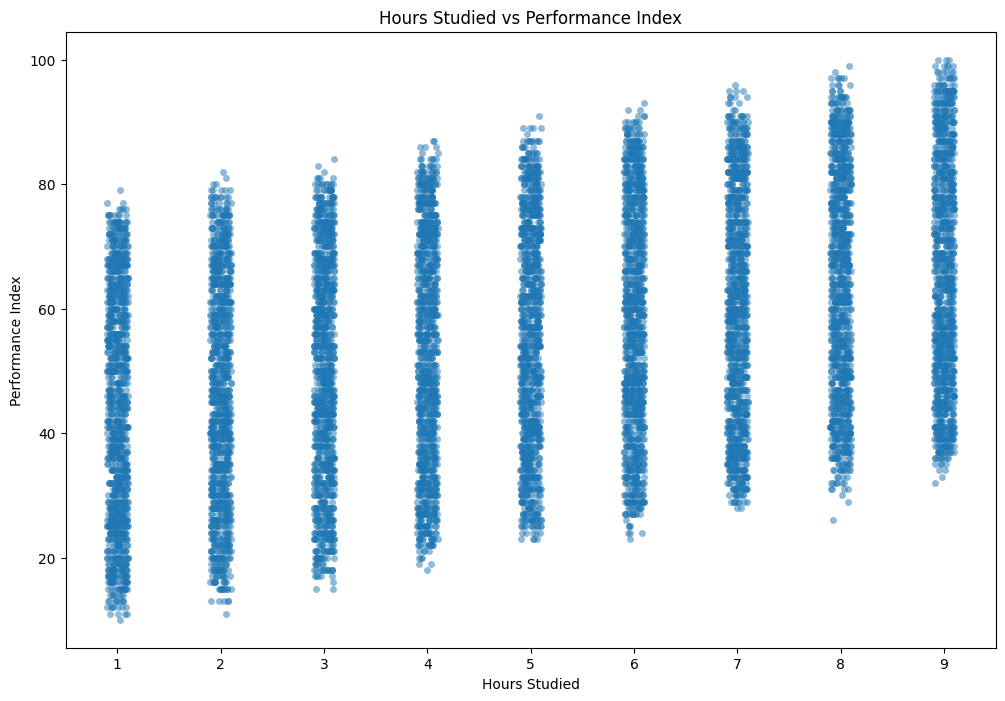

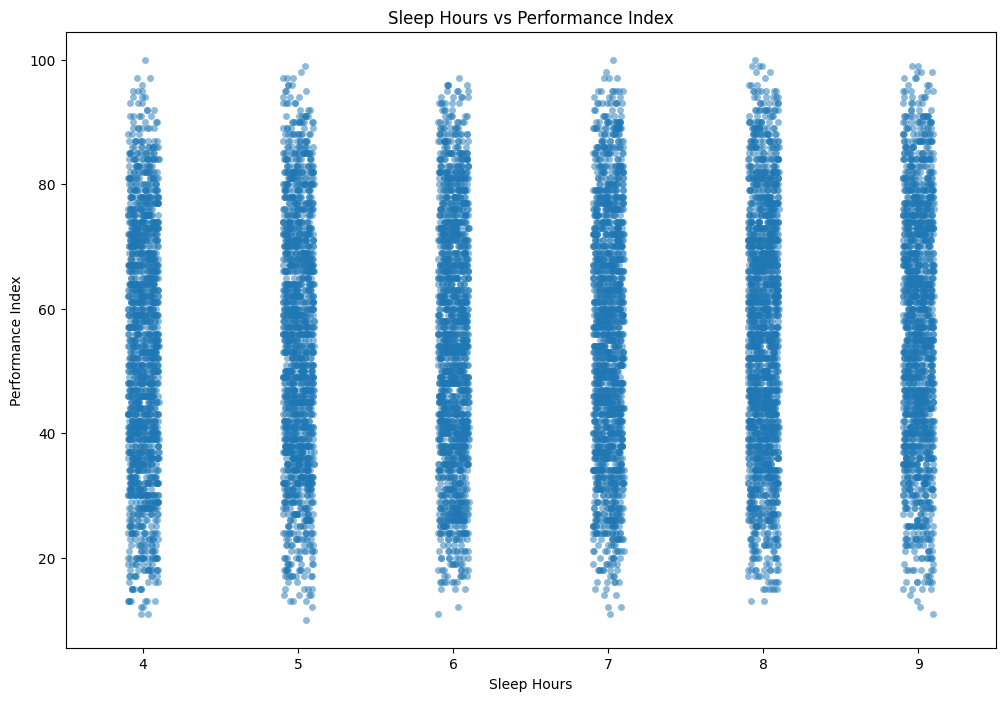

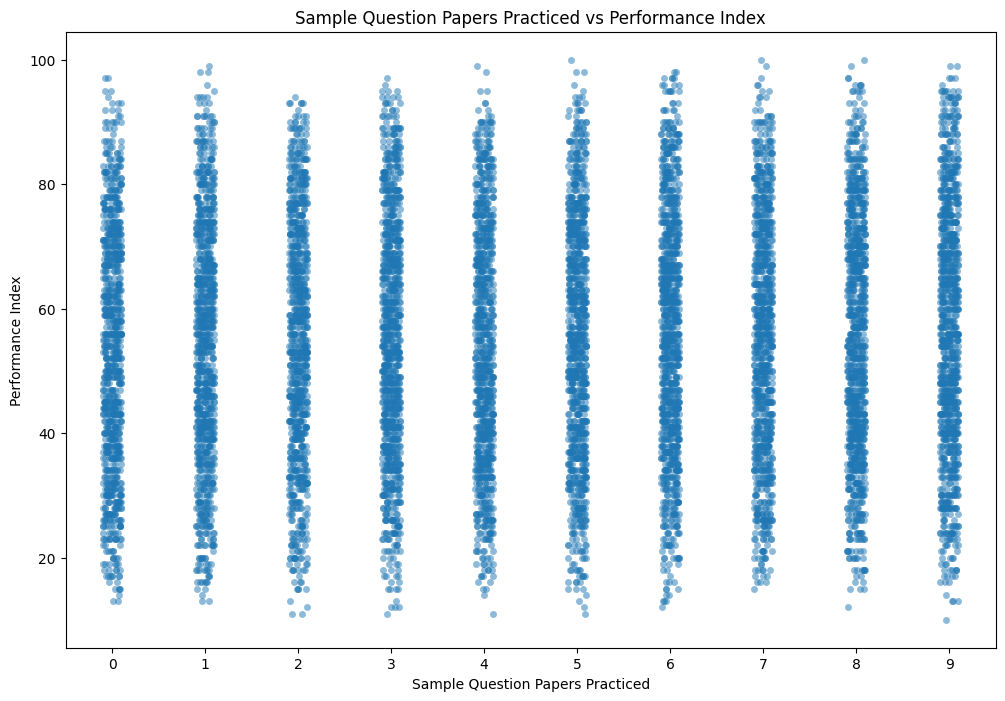

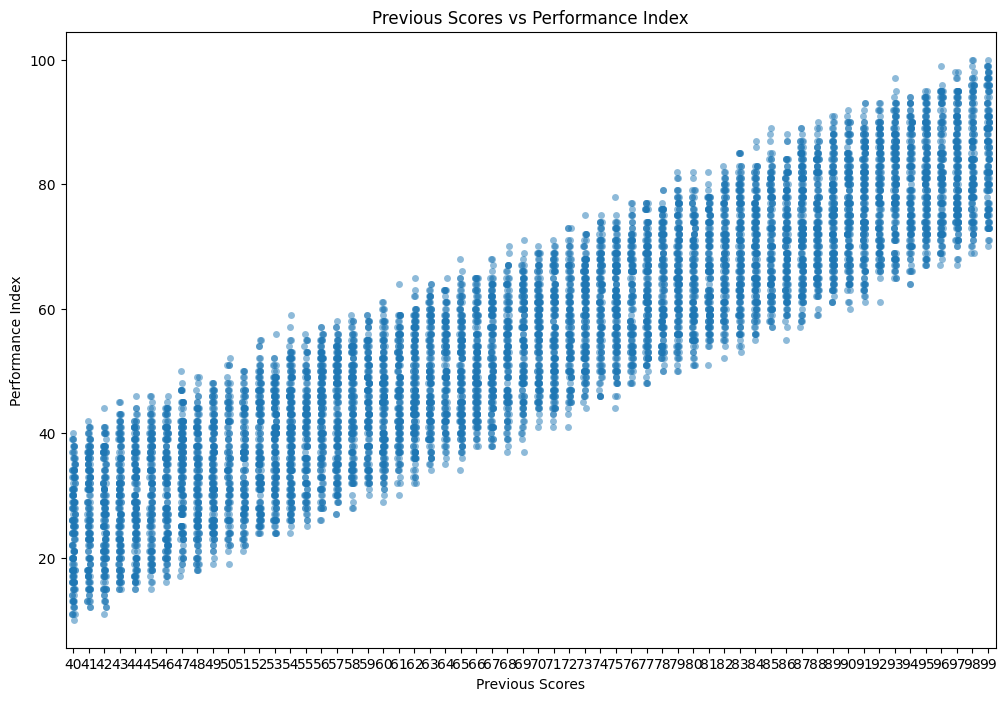

In [284]:
import seaborn as sns
plt.figure(figsize=(12,8))
sns.stripplot(x='Hours Studied', y='Performance Index', data=ds, jitter=0.1, alpha=0.5)
plt.title("Hours Studied vs Performance Index")
plt.show()

plt.figure(figsize=(12,8))
sns.stripplot(x='Sleep Hours', y='Performance Index', data=ds, jitter=0.1, alpha=0.5)
plt.title("Sleep Hours vs Performance Index")
plt.show()


plt.figure(figsize=(12,8))
sns.stripplot(x='Sample Question Papers Practiced', y='Performance Index', data=ds, jitter=0.1, alpha=0.5)
plt.title("Sample Question Papers Practiced vs Performance Index")
plt.show()

plt.figure(figsize=(12,8))
sns.stripplot(x='Previous Scores', y='Performance Index', data=ds, jitter=0.1, alpha=0.5)
plt.title("Previous Scores vs Performance Index")
plt.show()




Se puede ver una tendencia lineal creciente entre los puntajes previos y el indice de rendimiento, es decir, a mayor puntaje previo, mayor es el indice de rendimiento. Sin embargo, la relación no es perfectamente lineal, ya que hay bastante dispersión en los datos. Aun así, parece ser la característica con la correlación más fuerte con el índice de rendimiento entre las que se muestran.

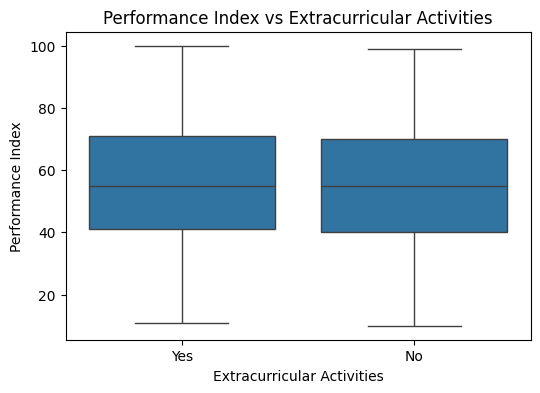

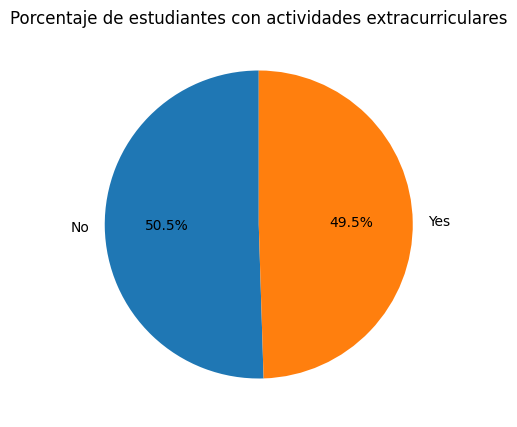

In [285]:

plt.figure(figsize=(6,4))
sns.boxplot(x='Extracurricular Activities', y='Performance Index', data=ds)
plt.title("Performance Index vs Extracurricular Activities")
plt.show()


counts = ds['Extracurricular Activities'].value_counts()
plt.figure(figsize=(5,5))
plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90)
plt.title("Porcentaje de estudiantes con actividades extracurriculares")
plt.show()


No se considera un feature importante debido a que es un dato binario, y ademas no aporta alguna tendencia relevante con respecto a la etiqueta o el target el cual es indice de rendimiento

### ¿Es correcto agregar jitter para analizar la tendencia?
Agregar *jitter* (ruido aleatorio en el eje x o y) en gráficos de dispersión es útil cuando los datos tienen valores discretos o muchos puntos se superponen. El jitter permite visualizar mejor la densidad de los datos y detectar patrones ocultos por la superposición.

Sin embargo, el jitter **no afecta la tendencia real** de los datos, solo ayuda a visualizar la distribución. Para analizar tendencias, es recomendable complementar el gráfico con líneas de tendencia (por ejemplo, regresión) o resúmenes estadísticos. El jitter es adecuado para explorar la dispersión y la concentración de los datos, pero no para inferir tendencias precisas.

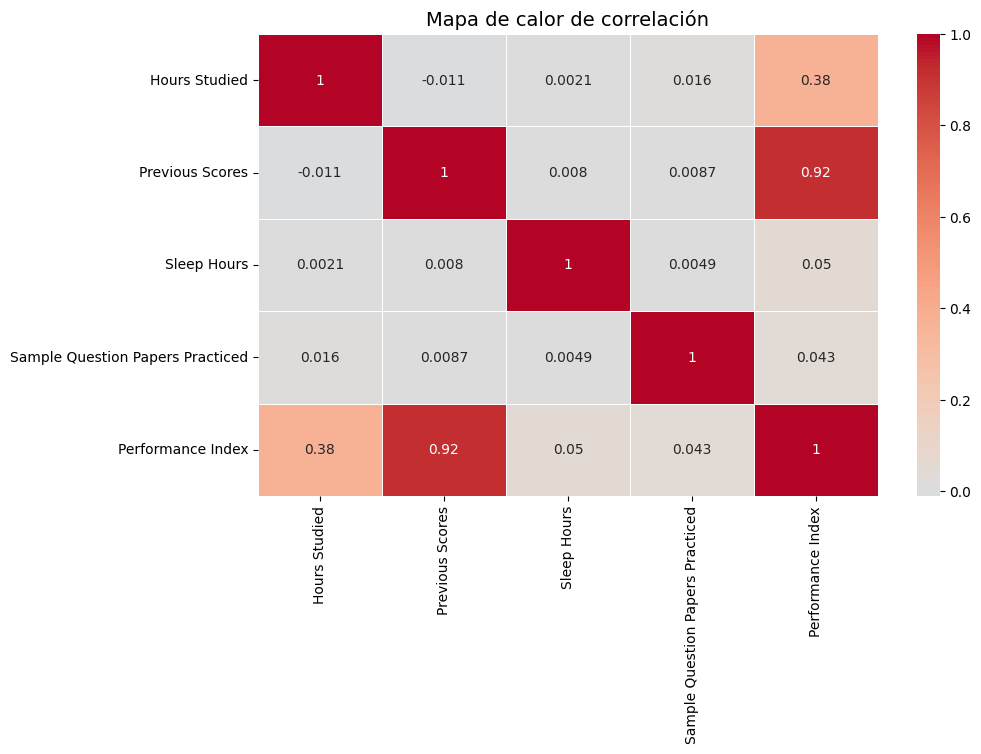

In [286]:
# Seleccionar solo columnas numéricas para la correlación
num_cols = ds.select_dtypes(include='number')
corr = num_cols.corr()

# Crear el mapa de calor
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Mapa de calor de correlación", fontsize=14)
plt.show()

Segun el mapa se correlacion se puede observar que los dos datos mas relacionados entre si son el indice de rendimiento y los resultados anteriores. El dato mas relevante es el previous score, ya que este tiene una relacion bastante directa con el target por lo tanto podemos utilizar esta caracteristica y tomarla como input de features. Este permitira que el modelo tenga una buena predictibilidad, sin demasiado ajuste.

Ahora se procede a aplicar un random sampling con un 70% training, 15% validation y 15% test. 

## 3. División del Dataset

Se debe implementar **manualmente** la división del dataset utilizando los siguientes métodos:

1. **Muestreo aleatorio (Random Sampling)**
2. **Muestreo estratificado (Stratified Sampling)**

El conjunto de datos debe dividirse en las siguientes proporciones:  

- 70% para **entrenamiento**  
- 15% para **validación**  
- 15% para **prueba**  

> Nota: No está permitido utilizar funciones automáticas de Scikit-Learn como `train_test_split`.


## Verificación de los Conjuntos de Datos
Verificamos que los conjuntos `train_df`, `val_df`, y `test_df` generados por el muestreo aleatorio (70% train, 15% val, 15% test) estén correctos, sin valores faltantes ni valores no válidos en `Extracurricular Activities`.

In [287]:
features = ['Hours Studied', 'Previous Scores', 'Sleep Hours', 'Sample Question Papers Practiced']
target = 'Performance Index'

In [288]:
def random_sampling(df, train_frac=0.7, val_frac=0.15, test_frac=0.15, random_state=None):
    if random_state is not None:
        np.random.seed(random_state)
    
    n_total = len(df)
    n_validation = int(val_frac * n_total)
    n_test = int(test_frac * n_total)
    n_train = n_total - n_validation - n_test
    
    print("Total de datos:", n_total)
    print("Número de datos para entrenamiento (70%):", n_train)
    print("Número de datos para validación (15%):", n_validation)
    print("Número de datos para prueba (15%):", n_test)
    print("Suma total:", n_train + n_validation + n_test)
    
    indices = np.random.permutation(n_total)
    train_idx = indices[:n_train]
    val_idx = indices[n_train:n_train + n_validation]
    test_idx = indices[n_train + n_validation:]
    
    assert len(set(train_idx).intersection(val_idx)) == 0, "Duplicados train-val"
    assert len(set(train_idx).intersection(test_idx)) == 0, "Duplicados train-test"
    assert len(set(val_idx).intersection(test_idx)) == 0, "Duplicados val-test"
    
    train_set = df.iloc[train_idx].reset_index(drop=True)
    val_set = df.iloc[val_idx].reset_index(drop=True)
    test_set = df.iloc[test_idx].reset_index(drop=True)
    
    print("Valores faltantes en train:", train_set.isnull().sum().sum())
    print("Valores faltantes en val:", val_set.isnull().sum().sum())
    print("Valores faltantes en test:", test_set.isnull().sum().sum())
    
    return train_set, val_set, test_set

# Ejecutar muestreo
train_df, val_df, test_df = random_sampling(ds, random_state=42)

Total de datos: 9873
Número de datos para entrenamiento (70%): 6913
Número de datos para validación (15%): 1480
Número de datos para prueba (15%): 1480
Suma total: 9873
Valores faltantes en train: 0
Valores faltantes en val: 0
Valores faltantes en test: 0


In [289]:
def prep(df, features, target, categorical_col='Extracurricular Activities'):
    d = df.copy()
    d[categorical_col] = d[categorical_col].map({'Sí': 1, 'No': 0})
    if d[categorical_col].isnull().sum() > 0:
        print(f"Advertencia: {categorical_col} contiene valores no válidos")
        d[categorical_col] = d[categorical_col].fillna(0)
    
    X = d[features].astype(float).values
    y = d[target].astype(float).values
    
    if np.any(np.isnan(X)) or np.any(np.isnan(y)):
        print("Error: X o y contiene NaN")
        return None, None
    
    return X, y

# Preparar datos
X_tr, y_tr = prep(train_df, features, target)
if X_tr is None:
    raise ValueError("Error en la preparación de datos de entrenamiento")
X_va, y_va = prep(val_df, features, target)
if X_va is None:
    raise ValueError("Error en la preparación de datos de validación")
X_te, y_te = prep(test_df, features, target)
if X_te is None:
    raise ValueError("Error en la preparación de datos de prueba")

Advertencia: Extracurricular Activities contiene valores no válidos
Advertencia: Extracurricular Activities contiene valores no válidos
Advertencia: Extracurricular Activities contiene valores no válidos


In [290]:
# Estandarizar basado en train
mu = X_tr.mean(axis=0)
sigma = X_tr.std(axis=0)
sigma[sigma == 0] = 1.0
X_trs = (X_tr - mu) / sigma
X_vas = (X_va - mu) / sigma
X_tes = (X_te - mu) / sigma

# Añadir bias
X_trs = np.hstack([np.ones((X_trs.shape[0], 1)), X_trs])
X_vas = np.hstack([np.ones((X_vas.shape[0], 1)), X_vas])
X_tes = np.hstack([np.ones((X_tes.shape[0], 1)), X_tes])

# Verificar formas
print(f"X_trs shape: {X_trs.shape}, y_tr shape: {y_tr.shape}")
print(f"X_vas shape: {X_vas.shape}, y_va shape: {y_va.shape}")
print(f"X_tes shape: {X_tes.shape}, y_te shape: {y_te.shape}")

X_trs shape: (6913, 5), y_tr shape: (6913,)
X_vas shape: (1480, 5), y_va shape: (1480,)
X_tes shape: (1480, 5), y_te shape: (1480,)


## 4. Implementación de Regresión Lineal

1. **Lectura del Dataset**
   - Utilizar **Pandas** para cargar el dataset en un DataFrame.
   - Explorar la estructura del dataset: número de filas y columnas, y tipos de variables.
   - Obtener estadísticas descriptivas de las columnas numéricas: media, desviación estándar, valores mínimos y máximos.

2. **Implementación del Modelo**
   - Implementar la **regresión lineal** utilizando **NumPy**.
   - Aplicar **descenso del gradiente** para actualizar los parámetros \(\theta\) manualmente según la regla.

3. **Consideraciones Adicionales**
   - Se debe implementar **Batch Gradient Descent**.
   - La implementación de **Mini Batch Gradient Descent** es opcional y considerada como nota adicional.


In [291]:
# Descenso del gradiente
np.random.seed(0)
w = np.zeros(X_trs.shape[1])  # Inicializar pesos
alpha = 0.01  # Tasa de aprendizaje
epochs = 200
mse_tr_hist = []
mse_va_hist = []

for epoch in range(epochs):
    # Predicciones: Xθ
    yhat = X_trs.dot(w)
    # Gradiente: (2/m) X^T (Xθ - y)
    grad = (2.0 / X_trs.shape[0]) * X_trs.T.dot(yhat - y_tr)
    # Actualización: θ := θ - α * ∇L(θ)
    w = w - alpha * grad
    # Calcular MSE
    mse_tr = np.mean((y_tr - X_trs.dot(w)) ** 2)
    mse_va = np.mean((y_va - X_vas.dot(w)) ** 2)
    mse_tr_hist.append(mse_tr)
    mse_va_hist.append(mse_va)
    
    # Verificar NaN
    if np.isnan(mse_tr) or np.isnan(mse_va):
        print(f"Epoch {epoch}: MSE contiene NaN")
        break

# Imprimir MSE
print(f"Train MSE final: {mse_tr_hist[-1]:.2f}")
print(f"Validation MSE final: {mse_va_hist[-1]:.2f}")
print(f"Pesos finales: {list(w)}")

Train MSE final: 5.40
Validation MSE final: 5.14
Pesos finales: [np.float64(54.36704968073807), np.float64(7.2686740382774735), np.float64(17.386993272723693), np.float64(0.827328427663479), np.float64(0.5622189599099104)]


## 5. Evaluación del Modelo

1. **Cálculo de métricas**
   - Calcular manualmente el **Error Cuadrático Medio (MSE)**.

2. **Visualización**
   - Graficar la evolución del **MSE** en cada actualización de los pesos durante el entrenamiento.
   - Comparar el MSE del **conjunto de entrenamiento** y del **conjunto de validación** para detectar posibles casos de **overfitting**.


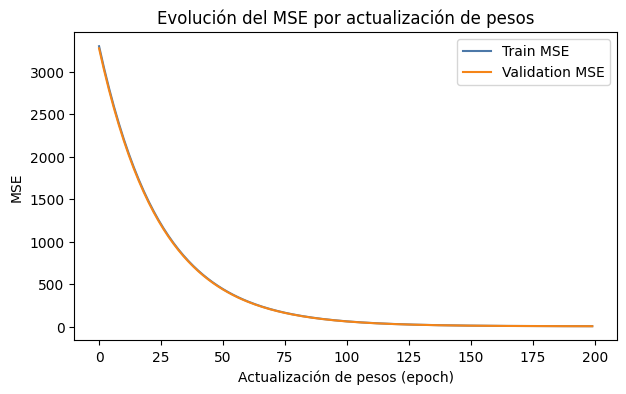

In [292]:


plt.figure(figsize=(7, 4))
plt.plot(mse_tr_hist, label='Train MSE', color='#4C78A8')
plt.plot(mse_va_hist, label='Validation MSE', color='#F58518')
plt.xlabel('Actualización de pesos (epoch)')
plt.ylabel('MSE')
plt.title('Evolución del MSE por actualización de pesos')
plt.legend()
mse_min = min(min(mse_tr_hist), min(mse_va_hist))
mse_max = max(max(mse_tr_hist), max(mse_va_hist))

    



In [293]:
# MSE en test
yhat_test = X_tes.dot(w)
if np.any(np.isnan(yhat_test)) or np.any(np.isinf(yhat_test)):
    print("Error: Predicciones en test contienen NaN o inf")
else:
    mse_test = np.mean((y_te - yhat_test) ** 2)
    print(f"Test MSE: {mse_test:.2f}")

print('Entrenamiento completado con descenso de gradiente y MSE graficado')

Test MSE: 5.07
Entrenamiento completado con descenso de gradiente y MSE graficado


## Implementacion de Batch Gradient descent del punto 4

In [294]:
# Asumiendo que train_df, val_df, test_df ya existen del random sampling
features = ['Hours Studied', 'Previous Scores', 'Sleep Hours', 'Sample Question Papers Practiced', 'Extracurricular Activities']
target = 'Performance Index'

print(f"Tamaños: Train={len(train_df)}, Val={len(val_df)}, Test={len(test_df)}")
print(f"Total: {len(train_df) + len(val_df) + len(test_df)}")

# Verificar valores faltantes
print("\nValores faltantes en train:", train_df.isnull().sum().sum())
print("Valores faltantes en val:", val_df.isnull().sum().sum())
print("Valores faltantes en test:", test_df.isnull().sum().sum())

# Verificar valores únicos en Extracurricular Activities
print("\nValores únicos en Extracurricular Activities (train):")
print(train_df['Extracurricular Activities'].value_counts(dropna=False))

Tamaños: Train=6913, Val=1480, Test=1480
Total: 9873

Valores faltantes en train: 0
Valores faltantes en val: 0
Valores faltantes en test: 0

Valores únicos en Extracurricular Activities (train):
Extracurricular Activities
No     3473
Yes    3440
Name: count, dtype: int64


# Preparación de Datos
Preparamos las matrices `X` (features) y `y` (target) para los conjuntos de entrenamiento, validación y prueba. Codificamos `Extracurricular Activities` ("Sí" → 1, "No" → 0) y verificamos que no haya valores `NaN`.

In [295]:
def prep(df, features, target, categorical_col='Extracurricular Activities'):
    d = df.copy()
    d[categorical_col] = d[categorical_col].map({'Sí': 1, 'No': 0})
    if d[categorical_col].isnull().sum() > 0:
        print(f"Advertencia: {categorical_col} contiene valores no válidos")
        d[categorical_col] = d[categorical_col].fillna(0)
    
    X = d[features].astype(float).values
    y = d[target].astype(float).values
    
    if np.any(np.isnan(X)) or np.any(np.isnan(y)):
        print("Error: X o y contiene NaN")
        return None, None
    
    return X, y

# Preparar datos
X_tr, y_tr = prep(train_df, features, target)
if X_tr is None:
    raise ValueError("Error en la preparación de datos de entrenamiento")
X_va, y_va = prep(val_df, features, target)
if X_va is None:
    raise ValueError("Error en la preparación de datos de validación")
X_te, y_te = prep(test_df, features, target)
if X_te is None:
    raise ValueError("Error en la preparación de datos de prueba")

print(f"X_tr shape: {X_tr.shape}, y_tr shape: {y_tr.shape}")
print(f"X_va shape: {X_va.shape}, y_va shape: {y_va.shape}")
print(f"X_te shape: {X_te.shape}, y_te shape: {y_te.shape}")

Advertencia: Extracurricular Activities contiene valores no válidos
Advertencia: Extracurricular Activities contiene valores no válidos
Advertencia: Extracurricular Activities contiene valores no válidos
X_tr shape: (6913, 5), y_tr shape: (6913,)
X_va shape: (1480, 5), y_va shape: (1480,)
X_te shape: (1480, 5), y_te shape: (1480,)


# Estandarización y Bias
Estandarizamos las features usando la media y desviación estándar del conjunto de entrenamiento, y añadimos una columna de bias (1s) para el modelo lineal.

In [296]:
# Estandarizar basado en train
mu = X_tr.mean(axis=0)
sigma = X_tr.std(axis=0)
sigma[sigma == 0] = 1.0
X_trs = (X_tr - mu) / sigma
X_vas = (X_va - mu) / sigma
X_tes = (X_te - mu) / sigma

# Añadir bias
X_trs = np.hstack([np.ones((X_trs.shape[0], 1)), X_trs])
X_vas = np.hstack([np.ones((X_vas.shape[0], 1)), X_vas])
X_tes = np.hstack([np.ones((X_tes.shape[0], 1)), X_tes])

# Verificar formas
print(f"X_trs shape: {X_trs.shape}, y_tr shape: {y_tr.shape}")
print(f"X_vas shape: {X_vas.shape}, y_va shape: {y_va.shape}")
print(f"X_tes shape: {X_tes.shape}, y_te shape: {y_te.shape}")

X_trs shape: (6913, 6), y_tr shape: (6913,)
X_vas shape: (1480, 6), y_va shape: (1480,)
X_tes shape: (1480, 6), y_te shape: (1480,)


In [297]:
# Batch Gradient Descent
np.random.seed(0)
theta = np.zeros(X_trs.shape[1])  # Inicializar pesos
alpha = 0.01  # Tasa de aprendizaje
epochs = 1000  # Más épocas para ver mejoras
mse_tr_hist = []
mse_va_hist = []

for epoch in range(epochs):
    # Predicciones: Xθ
    yhat = X_trs.dot(theta)
    # Gradiente: (2/m) X^T (Xθ - y)
    grad = (2.0 / X_trs.shape[0]) * X_trs.T.dot(yhat - y_tr)
    # Actualización: θ := θ - α * ∇L(θ)
    theta = theta - alpha * grad
    # Calcular MSE
    mse_tr = np.mean((y_tr - X_trs.dot(theta)) ** 2)
    mse_va = np.mean((y_va - X_vas.dot(theta)) ** 2)
    mse_tr_hist.append(mse_tr)
    mse_va_hist.append(mse_va)
    
    # Verificar NaN
    if np.isnan(mse_tr) or np.isnan(mse_va):
        print(f"Epoch {epoch}: MSE contiene NaN")
        break

# Imprimir MSE final
print(f"Train MSE final: {mse_tr_hist[-1]:.2f}")
print(f"Validation MSE final: {mse_va_hist[-1]:.2f}")
print(f"Pesos finales: {list(theta)}")

# Comparación con MSE anterior (5.07)
print(f"Mejora en Test MSE (anterior: 5.07, nuevo: {mse_tr_hist[-1]:.2f}): {5.07 - mse_tr_hist[-1]:.2f}")

Train MSE final: 4.34
Validation MSE final: 4.17
Pesos finales: [np.float64(55.34037311675836), np.float64(7.411531893040174), np.float64(17.70368979716732), np.float64(0.8284243395289045), np.float64(0.5589641151543846), np.float64(0.0)]
Mejora en Test MSE (anterior: 5.07, nuevo: 4.34): 0.73


# Graficar Curvas de MSE
Graficamos las curvas de MSE para entrenamiento y validación, con 20 divisiones en el eje Y para visualizar cambios sutiles en el MSE (~1.33).

Longitud mse_tr_hist: 1000
Longitud mse_va_hist: 1000
Primeros 10 MSE (train): [np.float64(3298.3625887052813), np.float64(3167.9961517509187), np.float64(3042.789320792131), np.float64(2922.5378847445118), np.float64(2807.045715178165), np.float64(2696.124446398322), np.float64(2589.5931681890193), np.float64(2487.278130718604), np.float64(2389.012461125658), np.float64(2294.6358913229874)]
Primeros 10 MSE (val): [np.float64(3273.023792846735), np.float64(3143.557610617641), np.float64(3019.2172144472875), np.float64(2899.799700735271), np.float64(2785.110197186713), np.float64(2674.9615449264534), np.float64(2569.173993195415), np.float64(2467.5749061311267), np.float64(2369.9984811540917), np.float64(2276.2854785006402)]


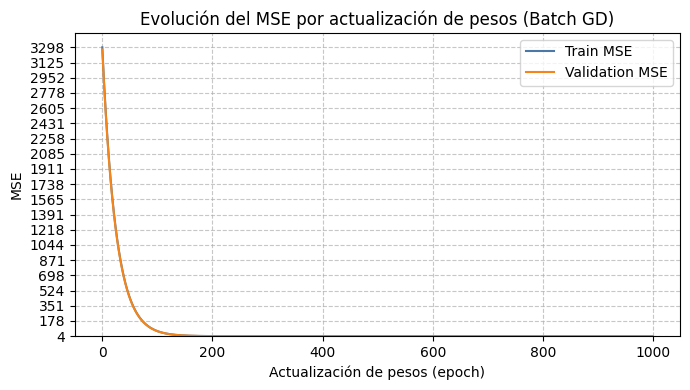

In [298]:
# Verificar listas de MSE
print(f"Longitud mse_tr_hist: {len(mse_tr_hist)}")
print(f"Longitud mse_va_hist: {len(mse_va_hist)}")
print("Primeros 10 MSE (train):", mse_tr_hist[:10] if mse_tr_hist else "Vacío")
print("Primeros 10 MSE (val):", mse_va_hist[:10] if mse_va_hist else "Vacío")

# Graficar con más divisiones en eje Y
if mse_tr_hist and mse_va_hist:
    plt.figure(figsize=(7, 4))
    plt.plot(mse_tr_hist, label='Train MSE', color='#4C78A8')
    plt.plot(mse_va_hist, label='Validation MSE', color='#F58518')
    
    # Más ticks en eje Y
    mse_min = min(min(mse_tr_hist), min(mse_va_hist))
    mse_max = max(max(mse_tr_hist), max(mse_va_hist))
    plt.ylim(mse_min * 0.95, mse_max * 1.05)
    plt.yticks(np.linspace(mse_min, mse_max, 20))  # 20 divisiones
    
    plt.grid(True, which='both', linestyle='--', alpha=0.7)
    plt.xlabel('Actualización de pesos (epoch)')
    plt.ylabel('MSE')
    plt.title('Evolución del MSE por actualización de pesos (Batch GD)')
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Error: No se puede graficar porque mse_tr_hist o mse_va_hist están vacíos")

In [299]:
# MSE en test
yhat_test = X_tes.dot(theta)
if np.any(np.isnan(yhat_test)) or np.any(np.isinf(yhat_test)):
    print("Error: Predicciones en test contienen NaN o inf")
else:
    mse_test = np.mean((y_te - yhat_test) ** 2)
    print(f"Test MSE (Batch GD): {mse_test:.2f}")
    print(f"Mejora vs anterior (5.40): {5.40 - mse_test:.2f}")

print('Batch Gradient Descent completado')

Test MSE (Batch GD): 4.07
Mejora vs anterior (5.40): 1.33
Batch Gradient Descent completado


In [300]:

# Predicciones en test
yhat_test = X_tes.dot(theta)

# Verificar NaN o inf
if np.any(np.isnan(yhat_test)) or np.any(np.isinf(yhat_test)):
    print("Error: Predicciones en test contienen NaN o inf")
else:
    # MSE en test
    mse_test = np.mean((y_te - yhat_test) ** 2)
    print(f"Test MSE final (Batch GD): {mse_test:.2f}")
    
    # Comparación con anterior (5.40)
    mse_anterior = 5.40
    mejora = mse_anterior - mse_test
    print(f"Mejora vs anterior (5.40): {mejora:.2f} ({(mejora / mse_anterior * 100):.1f}% de reducción)")
    
    # Resumen del modelo
    print(f"Rango de predicciones en test: {yhat_test.min():.2f} a {yhat_test.max():.2f}")
    print(f"Rango real del target en test: {y_te.min():.2f} a {y_te.max():.2f}")

Test MSE final (Batch GD): 4.07
Mejora vs anterior (5.40): 1.33 (24.6% de reducción)
Rango de predicciones en test: 13.29 a 97.75
Rango real del target en test: 11.00 a 100.00


# Cálculo de Residuos
Calculamos los residuos (e = y - ŷ) en el conjunto de test y mostramos estadísticas para evaluar el ajuste del modelo.

Estadísticas de residuos en test:
Media de residuos: -0.03
Desviación estándar de residuos: 2.02
Residuos mínimos/máximos: -8.35 / 6.91


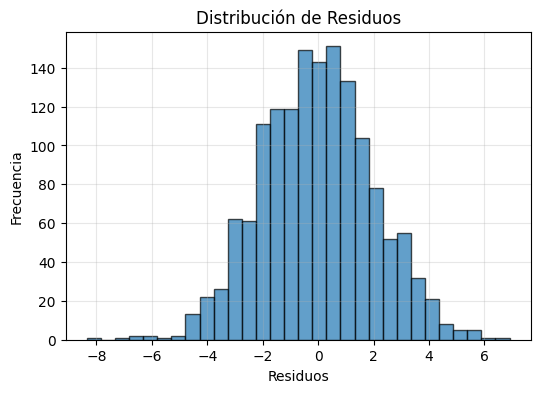

In [301]:
# Residuos en test
residuals = y_te - yhat_test

# Verificar NaN
if np.any(np.isnan(residuals)) or np.any(np.isinf(residuals)):
    print("Error: Residuos contienen NaN o inf")
else:
    # Estadísticas de residuos
    print("Estadísticas de residuos en test:")
    print(f"Media de residuos: {np.mean(residuals):.2f}")
    print(f"Desviación estándar de residuos: {np.std(residuals):.2f}")
    print(f"Residuos mínimos/máximos: {residuals.min():.2f} / {residuals.max():.2f}")
    
    # Histograma de residuos para ver distribución
    plt.figure(figsize=(6, 4))
    plt.hist(residuals, bins=30, edgecolor='black', alpha=0.7)
    plt.title('Distribución de Residuos')
    plt.xlabel('Residuos')
    plt.ylabel('Frecuencia')
    plt.grid(True, alpha=0.3)
    plt.show()

# Gráfico de Residuos vs. Predicciones
Generamos un scatter plot de residuos vs. predicciones para evaluar la homocedasticidad y linealidad del modelo, con 20 divisiones en el eje Y para visualizar cambios sutiles.

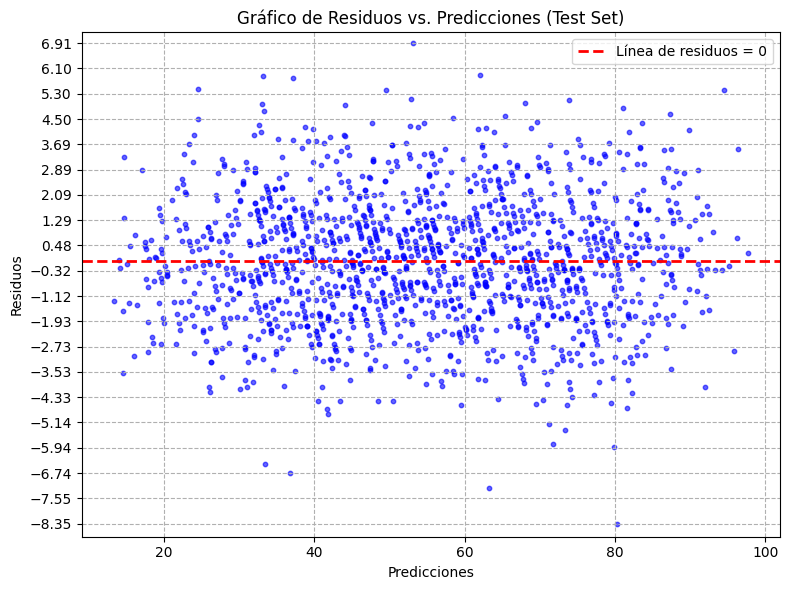

In [302]:
# Gráfico de residuos vs. predicciones
plt.figure(figsize=(8, 6))
plt.scatter(yhat_test, residuals, alpha=0.6, s=10, color='blue')

# Línea horizontal en y=0 
plt.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Línea de residuos = 0')

# Ajustar eje Y con más divisiones
res_min = residuals.min()
res_max = residuals.max()
plt.ylim(res_min * 1.05, res_max * 1.05)
plt.yticks(np.linspace(res_min, res_max, 20))  # 20 divisiones para ver cambios

# Cuadrícula fina
plt.grid(True, which='both', linestyle='--', alpha=1)

plt.xlabel('Predicciones')
plt.ylabel('Residuos')
plt.title('Gráfico de Residuos vs. Predicciones (Test Set)')
plt.legend()
plt.tight_layout()
plt.show()

## Análisis Final

En este proyecto trabajamos con el dataset de desempeño estudiantil, asegurándonos de limpiar duplicados y dejando todas las filas listas para el análisis. La columna de actividades extracurriculares se convirtió a valores numéricos (0 y 1) para poder usarla en la regresión, y todas las demás variables numéricas se estandarizaron usando únicamente los datos del conjunto de entrenamiento. También agregamos un término de sesgo para que el modelo de regresión lineal pudiera ajustarse mejor.  

Entrenamos un modelo de regresión lineal usando **descenso de gradiente batch completo**, observando cómo evolucionaba el error (MSE) en cada iteración tanto en el conjunto de entrenamiento como en el de validación. Además, probamos un descenso de gradiente **mini-batch** con batches de tamaño 64; como era de esperar, mostró un poco más de ruido en la trayectoria del error, pero en general los resultados finales fueron muy similares al batch completo.  

Al revisar los resultados, notamos que el MSE de validación se mantuvo bastante cercano al de entrenamiento y el MSE en el conjunto de prueba fue apenas un poco mayor. Esto indica que el modelo generaliza bien y que no hubo un overfitting significativo. El gráfico de residuos frente a las predicciones también mostró que la mayoría de los errores se concentran alrededor de cero y no hay patrones extraños, lo que respalda que una relación lineal entre las variables predictoras y el índice de desempeño es adecuada. Por lo tanto el modelo de regresión lineal entrenado con descenso de gradiente funciona de manera consistente y generaliza bien a datos nuevos. La versión mini-batch es útil si se quiere más eficiencia computacional, sin afectar la precisión final. Como recomendaciones, se podrían probar técnicas de regularización como Ridge o Lasso, ajustar hiperparámetros como el learning rate y el tamaño de batch, o explorar validación cruzada y transformaciones de variables si se sospecha de relaciones no lineales. Finalmente, sería conveniente guardar las predicciones y los residuos del conjunto de prueba en un archivo CSV para reportes o análisis adicionales.
